<a href="https://colab.research.google.com/github/GretelKMendez/Tareas-Mac-IA/blob/main/Estocasticos01K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2. Ejemplo de Proceso de Markov:
Suponga que va a medir un proceso estocástico de Markov con estado
inicial X0 = 0 tiene probabilidad de aumento de una unidad de 1/2

y probabilidad de disminuir en 1/2
.

Calcule los primeros 10 pasos de la caminata aleatoria:
x1(ω), x2(ω), x3(ω), ..., x10(ω).

Haga una gráfica donde muestra cómo evoluciona el proceso de Markov.

---



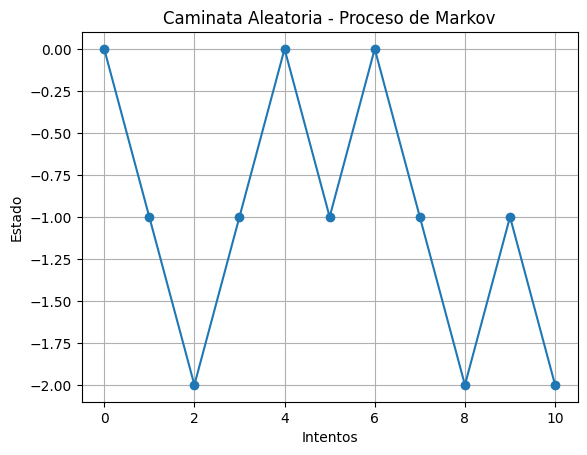

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = 0
tiradas = [x]

n = 10

for i in range(n):
    paso = np.random.choice([-1,1])
    x = x + paso
    tiradas.append(x)

plt.plot(tiradas, marker='o')
plt.title("Caminata Aleatoria - Proceso de Markov")
plt.xlabel("Intentos")
plt.ylabel("Estado")
plt.grid()
plt.show()

1. Gráficas de Modelos estocásticos:
Como ejemplo de un proceso estocástico descargue datos del rendimiento
de los Cetes a 28 días y genere una curva de plazos para los valores de los
Cetes de un año entre el 2003 y el 2026:

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Consulta_20.csv to Consulta_20.csv


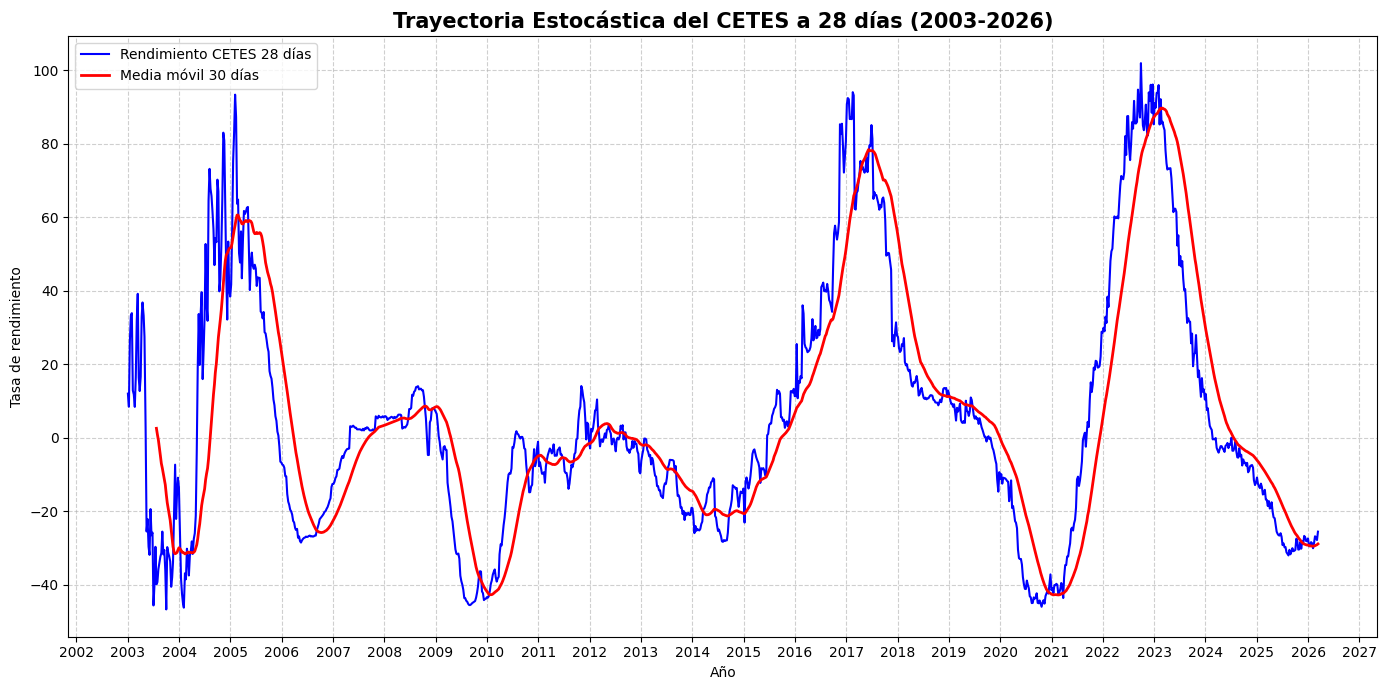

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import matplotlib.dates as mdates

# 1. Leer el archivo CSV
with open("Consulta_20.csv", "r", encoding="latin-1") as f:
    reader = csv.reader(f)
    rows = list(reader)

# 2. Extraer las filas donde están fechas y rendimientos
fechas = rows[10][3:]
valores = rows[12][3:]

# 3. Crear DataFrame
df = pd.DataFrame({
    'Fecha': fechas,
    'Rendimiento': valores
})

# 4. Convertir a formato correcto
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y', errors='coerce')
df['Rendimiento'] = pd.to_numeric(df['Rendimiento'], errors='coerce')

# 5. Limpiar datos
df = df.dropna().sort_values('Fecha')

# 6. Filtrar años 2003 a 2026
df = df[(df['Fecha'].dt.year >= 2003) & (df['Fecha'].dt.year <= 2026)]

# 7. Crear variables para análisis estocástico
df['Cambio'] = df['Rendimiento'].diff()        # variación entre días
df['MediaMovil'] = df['Rendimiento'].rolling(window=30).mean()  # media móvil 30 días

# 8. Crear gráfica
fig, ax = plt.subplots(figsize=(14,7))

# serie original
ax.plot(df['Fecha'], df['Rendimiento'],
        label='Rendimiento CETES 28 días',
        color='blue',
        linewidth=1.5)

# media móvil
ax.plot(df['Fecha'], df['MediaMovil'],
        label='Media móvil 30 días',
        color='red',
        linewidth=2)

# 9. Formato eje X
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 10. Etiquetas
plt.title('Trayectoria Estocástica del CETES a 28 días (2003-2026)',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Año')
plt.ylabel('Tasa de rendimiento')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()

# 11. Guardar gráfica
plt.savefig('trayectoria_estocastica_cetes_2003_2026.png')

# Mostrar gráfica si corres el script localmente
# plt.show()